In [45]:
# Import necessary libraries
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Load the dataset
# Make sure the 'restrnt_Dataset .csv' file is in the same directory as your notebook
try:
    df = pd.read_csv('/Users/abdulsubhan/Downloads/restrnt_Dataset .csv', encoding='utf-8')
    print("Dataset loaded successfully! Let's get cooking.")
except FileNotFoundError:
    print("Error: 'restrnt_Dataset .csv' not found. Please ensure the file is in the correct directory.")

# Display the first few rows to see what we're working with
display(df.head())

Dataset loaded successfully! Let's get cooking.


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [46]:
# Select the columns we need for our recommender
recommender_df = df[[
    'Restaurant ID', 'Restaurant Name', 'Cuisines', 
    'Locality', 'Price range', 'Aggregate rating', 'Votes'
]].copy()

# --- Handle Missing Values ---
# If a restaurant's cuisine is not listed, we'll mark it as 'Not Specified'.
recommender_df['Cuisines'].fillna('Not Specified', inplace=True)

# --- Feature Engineering: Create a combined 'profile' for each restaurant ---
# We'll combine the key features into a single string. This string will act as the
# unique "flavor profile" of each restaurant.
# We are replacing spaces in Cuisines and Locality to treat multi-word names as single entities.
recommender_df['Cuisines'] = recommender_df['Cuisines'].str.replace(' ', '')
recommender_df['Locality'] = recommender_df['Locality'].str.replace(' ', '')

recommender_df['profile'] = (
    recommender_df['Cuisines'] + ' ' + 
    recommender_df['Locality'] + ' ' + 
    'PriceRange' + recommender_df['Price range'].astype(str)
)

# Convert the profile text to lowercase for consistency
recommender_df['profile'] = recommender_df['profile'].str.lower()

print("\nDataset after creating the 'profile' column:")
display(recommender_df.head())


Dataset after creating the 'profile' column:


/var/folders/cs/06pk1l757wq6wsgssnj9rzn00000gn/T/ipykernel_12393/29558846.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  recommender_df['Cuisines'].fillna('Not Specified', inplace=True)


,Restaurant ID,Restaurant Name,Cuisines,Locality,Price range,Aggregate rating,Votes,profile
0,6317637,Le Petit Souffle,"French,Japanese,Desserts","CenturyCityMall,Poblacion,MakatiCity",3,4.8,314,"french,japanese,desserts centurycitymall,pobla..."
1,6304287,Izakaya Kikufuji,Japanese,"LittleTokyo,LegaspiVillage,MakatiCity",3,4.5,591,"japanese littletokyo,legaspivillage,makaticity..."
2,6300002,Heat - Edsa Shangri-La,"Seafood,Asian,Filipino,Indian","EdsaShangri-La,Ortigas,MandaluyongCity",4,4.4,270,"seafood,asian,filipino,indian edsashangri-la,o..."
3,6318506,Ooma,"Japanese,Sushi","SMMegamall,Ortigas,MandaluyongCity",4,4.9,365,"japanese,sushi smmegamall,ortigas,mandaluyongc..."
4,6314302,Sambo Kojin,"Japanese,Korean","SMMegamall,Ortigas,MandaluyongCity",4,4.8,229,"japanese,korean smmegamall,ortigas,mandaluyong..."


In [3]:
# Initialize the TF-IDF Vectorizer
tfidf = TfidfVectorizer(stop_words='english')

# Create the TF-IDF matrix by fitting and transforming the data
tfidf_matrix = tfidf.fit_transform(recommender_df['profile'])

# --- Calculate the Cosine Similarity Matrix ---
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f"Successfully created a similarity matrix of shape: {cosine_sim.shape}")

Successfully created a similarity matrix of shape: (9551, 9551)


In [71]:
def get_restaurant_recommendations(cuisine, locality, price_range, top_n=5):
    """
    Recommends restaurants based on user preferences using content-based filtering.
    """
    # Create a user profile string in the same format as our dataset
    user_profile = (cuisine.replace(' ', '') + ' ' + 
                    locality.replace(' ', '') + ' ' + 
                    'PriceRange' + str(price_range)).lower()
    
    # Transform the user profile into a TF-IDF vector
    user_vector = tfidf.transform([user_profile])
    
    # Calculate the cosine similarity between the user and all restaurants
    sim_scores = cosine_similarity(user_vector, tfidf_matrix).flatten()
    
    # Get the indices of the top N most similar restaurants
    # We use argsort to get the indices and then slice the top N+1 (to handle potential self-match)
    top_indices = sim_scores.argsort()[-top_n-1:][::-1]
    
    # Filter out restaurants with very low ratings or votes for better quality
    recommended_restaurants = recommender_df.iloc[top_indices]
    
    # Quality control: ensure recommendations have a decent rating and number of votes
    quality_recommendations = recommended_restaurants[
        (recommended_restaurants['Aggregate rating'] > 3.5) & 
        (recommended_restaurants['Votes'] > 50)
    ]

    if quality_recommendations.empty:
        return "Sorry, couldn't find any high-quality matches. Try broadening your criteria!"
        
    return quality_recommendations.head(top_n)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

/var/folders/cs/06pk1l757wq6wsgssnj9rzn00000gn/T/ipykernel_12393/3047889857.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Price range', data=df, palette="mako")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

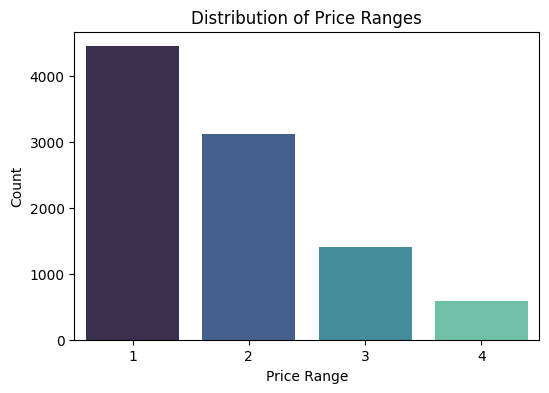

In [74]:
#  Price range distribution
plt.figure(figsize=(6,4))
sns.countplot(x='Price range', data=df, palette="mako")
plt.title("Distribution of Price Ranges")
plt.xlabel("Price Range")
plt.ylabel("Count")
plt.show()

In [72]:
# --- Test Case 1 ---
print("--- Recommendation Request 1 ---")
print("User wants: Japanese food, Price Range 3, in Little Tokyo, Legaspi Village, Makati City\n")

recommendations_1 = get_restaurant_recommendations(
    cuisine='Japanese',
    locality='Little Tokyo, Legaspi Village, Makati City',
    price_range=3
)
display(recommendations_1)

--- Recommendation Request 1 ---
User wants: Japanese food, Price Range 3, in Little Tokyo, Legaspi Village, Makati City



,Restaurant ID,Restaurant Name,Cuisines,Locality,Price range,Aggregate rating,Votes,profile
1,6304287,Izakaya Kikufuji,Japanese,"LittleTokyo,LegaspiVillage,MakatiCity",3,4.5,591,"japanese littletokyo,legaspivillage,makaticity..."
0,6317637,Le Petit Souffle,"French,Japanese,Desserts","CenturyCityMall,Poblacion,MakatiCity",3,4.8,314,"french,japanese,desserts centurycitymall,pobla..."


In [73]:
# --- Test Case 2 ---
print("\n--- Recommendation Request 2 ---")
print("User wants: South Indian , Price Range 2, in New Delhi\n")

recommendations_2 = get_restaurant_recommendations(
    cuisine='South Indian',
    locality='New Delhi',
    price_range=2,
    top_n=5
)
display(recommendations_2)


--- Recommendation Request 2 ---
User wants: South Indian , Price Range 2, in New Delhi



,Restaurant ID,Restaurant Name,Cuisines,Locality,Price range,Aggregate rating,Votes,profile
3110,900,Saravana Bhavan,SouthIndian,ConnaughtPlace,2,4.3,5172,southindian connaughtplace pricerange2
4452,412,Naivedyam,SouthIndian,Kalkaji,2,3.8,495,southindian kalkaji pricerange2
4320,899,Saravana Bhavan,SouthIndian,Janpath,2,4.2,1869,southindian janpath pricerange2
